# 03 · Machine unlearning with weightless networks — **exact, instant, by design**

A static benchmark asks one question: *who is most accurate on a frozen test set?*
On that question (notebook `02`) a random forest wins and WiSARD is a competitive
runner-up. But a deployed recogniser is rarely frozen, and one operation the static
leaderboard never scores is the one regulators now **require**: *delete this data and
make the model behave as if it had never seen it.* That is **machine unlearning**, and
it is where weightless networks are not merely competitive but **structurally
advantaged** — because forgetting is, for WiSARD, a primitive rather than a repair.

This notebook makes unlearning the spine. We frame the problem and the field's
evaluation standards (§0), then benchmark WiSARD's `untrain` against the machine-unlearning
**SOTA** on five concrete Waldo scenarios: right-to-be-forgotten class erasure with an
**exactness certificate** (§1), poisoned-sample removal (§2), **unlearning at scale** under a
stream of deletion requests (§3), continual unlearning under drift (§4), and **backdoor/trojan
scrubbing** in a sliding-window detector (§5). Throughout we score on a uniform
**cost × retained-utility** view with a **membership-inference** forgetting-quality probe, and
draw the contrast that matters once approximate methods are shown to leak: against the **exact**
SOTA — retrain-from-scratch and SISA. The honest claim is not "WiSARD is more accurate"; it is
that WiSARD occupies a corner of the unlearning trade-off — *exact, ~zero-cost, residual-free, single-digit-MB, byte-auditable* — that
the exact SOTA (SISA, retrain-from-scratch, the purpose-built DaRE forest) reaches only by spending
one-to-two orders of magnitude more compute or memory, and that
approximate methods reach on cost only by giving up exactness and leaking.

## §0 · What machine unlearning is, and how the field scores it

**Why it matters.** The *right to be forgotten* (GDPR Art. 17, CCPA) gives a data
subject the right to have their data — and its *influence on trained models* — removed.
The same operation is needed for **poison / mislabel correction** (excise corrupted
training records) and **copyright takedown** (remove memorised protected content). The
naive solution, *retrain from scratch on the remaining data*, is correct but often
prohibitively expensive, so a whole field has grown to do it cheaply.

**Exact vs. approximate.** Methods split into two camps:

- **Exact unlearning** guarantees the deleted data's influence is *completely* gone.
  The gold standard is **retrain-from-scratch-without-it**; the practical SOTA is
  **SISA** (Bourtoule et al., *IEEE S&P 2021*): shard the data, train one constituent
  model per shard, and on a deletion request **retrain only the shard(s) that held the
  deleted samples**. Exact, but you pay a shard-retrain per request and per-shard
  utility degrades as the shard count grows.
- **Approximate unlearning** edits the trained weights to *approximate* the retrained
  model without rebuilding — e.g. **gradient ascent / fine-tune-to-forget**, influence
  functions / certified removal, Fisher "scrubbing". Cheap and scalable, but **not
  exact**: residual memorisation can remain.

**How forgetting quality is measured.** Because approximate methods don't guarantee
removal, the field evaluates them with a **membership-inference attack (MIA)**: after
unlearning, can an attacker still tell that a "forgotten" sample was once in training?
Models assign higher confidence to data they memorised, so a deleted sample that still
scores *member-like* signals a leak. A correct unlearn makes deleted samples
indistinguishable from never-seen ones (**MIA AUC ≈ 0.5**); the retrain-from-scratch
gold standard achieves this by construction.

**Unlearning by design.** The newest direction builds models whose *architecture* makes
forgetting native — e.g. **MUNKEY** (ICLR 2026 wksp): a memory-augmented transformer
that externalises instance memorisation into keys, so unlearning becomes **zero-shot
key deletion**, no weight updates and no access to the original samples. WiSARD has had
this property **by construction since the 1980s**: it learns by *writing patterns into
RAM* and unlearns by *erasing exactly those RAM writes* (`untrain` / `untrainSingle`),
with one independent discriminator per class. The RAM address *is* the key; erasing it
needs neither labels nor a retrain, costs `O(samples removed)`, touches no other class,
and leaves the model **byte-identical to never having seen the data**. We did not find a
prior paper making the *WiSARD-as-exact-unlearner* argument — the intersection is empty.

**What we benchmark.** Four (model, unlearning-mechanism) solutions, compared as
*unlearning solutions* on identical forget/retain splits:

| Solution | Mechanism | Exact? | Cost to forget |
|---|---|---|---|
| **WiSARD + `untrain`** | erase the exact RAM writes | **yes** (by construction) | `O(samples removed)` |
| **RF + retrain (gold)** | retrain-from-scratch on retain set | yes (reference) | full rebuild |
| **RF + SISA** | retrain only affected shards | yes | #affected-shards rebuilds |
| **Logistic + grad-ascent** | ascend loss on the forget set | **no** (approximate) | a few gradient steps |

RF keeps the *static-accuracy* crown throughout — we never dispute it. We measure the
**cost and quality of forgetting**, the axis the leaderboard ignores.

In [1]:
import sys, importlib, time, json, warnings
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import characters as C, bench
for _m in (C, bench): importlib.reload(_m)
import wisardpkg as wp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
np.set_printoptions(suppress=True)

ORDER = ['background', 'waldo', 'odlaw', 'wenda', 'wizard', 'woof']
IDX   = {c: C.CLASS_TO_IDX[c] for c in ORDER}
CLASSES = [IDX[c] for c in ORDER]
NTR, NTE, CANON = 120, 60, 24
COL = {'WiSARD': '#E45756', 'RF-gold': '#4C78A8', 'SISA': '#72B7B2', 'GradAscent': '#B279A2', 'DaRE-greedy': '#54A24B', 'DaRE-random': '#88C4A0', 'poison': '#d88'}

# --- tuned configs (the fairness fix) --------------------------------------
WIS = json.load(open('cache/best_wisard.json'))                      # notebook 01 grid winner
RF_BEST = dict(n_estimators=300, max_depth=16, max_features='sqrt')  # notebook 02 grid winner
print('WiSARD (tuned):', WIS, ' · RF (tuned):', RF_BEST)

# Encoder is a DESIGN-TIME choice (notebook 01): fit the thermometer once on a calibration
# draw across all classes, then FREEZE it so RAM addresses stay aligned across every stage.
Xcal, _ = C.make_dataset(40, size=48, seed=999, classes=ORDER, **C.PRESETS['clean'])
THERM = bench.fit_thermometer(bench.to_canon(Xcal, CANON), WIS['kind'], WIS['size'])
def bits(Xc): return bench.thermometer_encode(Xc, THERM)
def feats(Xc): return bench.raw_float(Xc)
def mk_wisard(addr=WIS['addr']): return wp.Wisard(addr)
def mk_rf(**kw): return RandomForestClassifier(n_jobs=1, random_state=1, **{**RF_BEST, **kw})  # single-thread: cost = algorithmic work, not core count
NBITS = bits(bench.to_canon(Xcal[:1], CANON)).shape[1]
NRAMS = NBITS // WIS['addr']                                          # RAM rows per discriminator

def mk_ds(Xc, y):
    ds = wp.DataSet()
    for b, l in zip(bits(Xc), y): ds.add(b.tolist(), str(int(l)))
    return ds
def wnn_predict(m, Xc):
    q = wp.DataSet()
    for b in bits(Xc): q.add(b.tolist(), '0')
    return np.array([int(o) for o in m.classify(q)])
def wnn_conf(m, Xc, ylab):
    '''Membership score per sample: normalised RAM-response of m on each sample's CLAIMED
       label (rank[label]/NRAMS in [0,1]). Higher = the model fires more rows for that
       (pattern,label) pair = more memorised.'''
    q = wp.DataSet()
    for b in bits(Xc): q.add(b.tolist(), '0')
    ranks = m.rank(q)
    return np.array([r.get(str(int(t)), 0) / NRAMS for r, t in zip(ranks, ylab)])

def pools(preset, order, ntr=NTR, nte=NTE):
    '''Per-class train pools + a pooled test set, at a given difficulty.'''
    k = C.PRESETS[preset]; tr = {}
    for c in order:
        X, y = C.make_dataset(ntr, size=48, seed=100 + C.CLASS_TO_IDX[c], classes=[c], **k)
        tr[c] = (bench.to_canon(X, CANON), y)
    Xte, yte = [], []
    for c in order:
        X, y = C.make_dataset(nte, size=48, seed=500 + C.CLASS_TO_IDX[c], classes=[c], **k)
        Xte.append(bench.to_canon(X, CANON)); yte.append(y)
    return tr, np.concatenate(Xte), np.concatenate(yte)
print('setup ready ·', len(ORDER), 'classes ·', NBITS, 'bits/sample ·', NRAMS, 'RAMs/discriminator')

WiSARD (tuned): {'kind': 'gaussian', 'size': 13, 'addr': 12}  · RF (tuned): {'n_estimators': 300, 'max_depth': 16, 'max_features': 'sqrt'}
setup ready · 6 classes · 22464 bits/sample · 1872 RAMs/discriminator


## Unlearning methods — the shared harness

We now fix a single training corpus (all six classes, tuned configs) and define the four
unlearning mechanisms so §2 and §3 can invoke them identically. Each mechanism answers the
same request — *delete a specified set of training rows and behave as if they were never
seen* — and is scored on the same axes:

- **cost** — wall-clock seconds for the *deletion* alone (not the initial training); **all methods run
  single-threaded** (`n_jobs=1`), so cost reflects algorithmic work, not core count;
- **retained utility** — test accuracy on the data we are *keeping*, after deletion;
- **forget effect** — accuracy on the deleted target (a correct deletion drives it to chance/0);
- **exactness** — whether the result provably equals retrain-from-scratch (yes for WiSARD /
  SISA / gold; no for gradient ascent);
- **MIA AUC** — a confidence-threshold membership-inference attack: using the *unlearned*
  model's confidence on each sample's claimed label, how well can an attacker separate the
  **deleted** samples (members) from **fresh never-seen** samples of the same kind
  (non-members)? **0.5 = indistinguishable = clean forgetting**; `>0.5` = residual leak.

In [2]:
# ---- SISA over RF: shard, train one constituent per shard, retrain only affected shards ----
def sisa_train(Xf, y, k=5, seed=0, pin=None):
    '''Random k-way shard. `pin` (indices) are forced into ONE shard — SISA's intended
       layout, sharding by source so a contributor's rows localise to a single shard.'''
    pin = np.array([], int) if pin is None else np.array(pin, int)
    rest = np.setdiff1d(np.arange(len(y)), pin)
    perm = np.random.RandomState(seed).permutation(rest)
    shards = [np.array(s, int) for s in np.array_split(perm, k)]
    if len(pin): shards[0] = np.concatenate([shards[0], pin])
    models = [mk_rf().fit(Xf[s], y[s]) for s in shards]
    return models, shards
def _shard_proba(m, Xf):
    P = np.zeros((len(Xf), len(CLASSES))); pp = m.predict_proba(Xf)
    for j, c in enumerate(m.classes_): P[:, CLASSES.index(int(c))] = pp[:, j]
    return P
def sisa_predict(models, Xf):
    P = sum(_shard_proba(m, Xf) for m in models)
    return np.array(CLASSES)[P.argmax(1)]
def sisa_conf(models, Xf, ylab):
    P = sum(_shard_proba(m, Xf) for m in models); P = P / P.sum(1, keepdims=True)
    return np.array([P[i, CLASSES.index(int(t))] for i, t in enumerate(ylab)])
def sisa_delete(models, shards, Xf, y, del_idx):
    dn = set(int(i) for i in del_idx); models = list(models); t = 0.0; hit = 0
    for i, s in enumerate(shards):
        if dn & set(int(j) for j in s):
            keep = [int(j) for j in s if int(j) not in dn]
            t0 = time.time(); models[i] = mk_rf().fit(Xf[keep], y[keep]); t += time.time() - t0; hit += 1
    return models, t, hit

# ---- logistic regression (numpy multinomial) + gradient-ASCENT unlearning ----
def _softmax(Z): Z = Z - Z.max(1, keepdims=True); e = np.exp(Z); return e / e.sum(1, keepdims=True)
def _onehot(y):
    Y = np.zeros((len(y), len(CLASSES)))
    for i, t in enumerate(y): Y[i, CLASSES.index(int(t))] = 1
    return Y
class LR:
    def __init__(self, mu, sd): self.mu, self.sd, self.W, self.b = mu, sd, None, None
    def _x(self, Xf): return (Xf - self.mu) / self.sd
    def fit(self, Xf, y, iters=400, lr=0.5, l2=1e-3, W=None, b=None):
        X = self._x(Xf); n, d = X.shape; Y = _onehot(y)
        self.W = np.zeros((d, len(CLASSES))) if W is None else W.copy()
        self.b = np.zeros(len(CLASSES)) if b is None else b.copy()
        for _ in range(iters):
            P = _softmax(X @ self.W + self.b)
            self.W -= lr * (X.T @ (P - Y) / n + l2 * self.W); self.b -= lr * (P - Y).mean(0)
        return self
    def ascend(self, Xf_forget, y_forget, Xf_retain, y_retain, steps=30, lr=0.1, l2=1e-3):
        '''Approximate unlearn: NORMALISED gradient ascent on the forget set (bounded step) with an
           L2-anchored full-batch descent on the retain set. Stable, but with no exactness
           certificate — push it to forget harder and it dents utility; keep utility and it leaks.'''
        Xf, Yf = self._x(Xf_forget), _onehot(y_forget)
        Xr, Yr = self._x(Xf_retain), _onehot(y_retain); n = len(Xr)
        for _ in range(steps):
            P = _softmax(Xf @ self.W + self.b); g = Xf.T @ (P - Yf) / len(Xf); g = g / (np.linalg.norm(g) + 1e-9)
            self.W += lr * g
            Pr = _softmax(Xr @ self.W + self.b)
            self.W -= lr * (Xr.T @ (Pr - Yr) / n + l2 * self.W); self.b -= lr * (Pr - Yr).mean(0)
        return self
    def predict(self, Xf): return np.array(CLASSES)[_softmax(self._x(Xf) @ self.W + self.b).argmax(1)]
    def conf(self, Xf, ylab):
        P = _softmax(self._x(Xf) @ self.W + self.b)
        return np.array([P[i, CLASSES.index(int(t))] for i, t in enumerate(ylab)])

def mia_auc(conf_member, conf_nonmember):
    yv = np.r_[np.ones(len(conf_member)), np.zeros(len(conf_nonmember))]
    sv = np.r_[conf_member, conf_nonmember]
    return roc_auc_score(yv, sv) if len(set(yv)) == 2 else 0.5
print('unlearning harness ready: WiSARD untrain · RF-gold retrain · SISA(k=5) · LR grad-ascent · MIA')

# ---- DaRE forests (Brophy & Lowd, ICML 2021): the purpose-built EXACT RF-unlearning SOTA ----
# We benchmark against the AUTHORS' published package (binary DaRE-RF). It does not build on this
# notebook's Python 3.13 (its PyPI sdist omits the Cython sources), so it runs in a dedicated py3.12
# env and is invoked through dare_real.py; results cache under cache/. Multiclass = one-vs-rest (one
# binary forest per class) — the faithful reduction, and a structural mirror of WiSARD's
# one-discriminator-per-class layout. Both regimes are EXACT by construction (Brophy & Lowd 2021):
#   greedy  (topd=0)         -> accuracy ~ RF-gold, but deletes rebuild subtrees + the cache is large
#   random  (topd=max_depth) -> cheap O(depth) deletes, lower accuracy, small cache
# Config matched to RF-gold (n_estimators=300, max_depth=16, max_features=sqrt, gini). k=25 is the
# no. candidate thresholds/attribute for greedy splits; a k in {25,50,100} sweep leaves greedy
# accuracy at 0.95 (saturated) and random accuracy at 0.853 (k-independent) — not a k artifact.
import os, subprocess
DARE_PY = os.path.expanduser('~/.pyenv/versions/dare-rf/bin/python')   # py3.12 env with dare-rf
DARE_REAL = './dare_real.py'
DARE_CFG = {'DaRE-greedy': dict(topd=0,  k=25, n_estimators=300, max_features='sqrt', max_depth=16, criterion='gini', random_state=1),
            'DaRE-random': dict(topd=99, k=25, n_estimators=300, max_features='sqrt', max_depth=16, criterion='gini', random_state=1)}
def dare_bridge(tag, arrays):
    '''Run the authors' dare-rf (py3.12 env, one-vs-rest) for one scenario; cache the JSON result.'''
    out = f'cache/dare_real_{tag}.json'
    if not os.path.exists(out):
        os.makedirs('cache/dare_io', exist_ok=True)
        np.savez(f'cache/dare_io/in_{tag}.npz', **arrays)
        subprocess.run([DARE_PY, DARE_REAL, tag, 'cache/dare_io', json.dumps(DARE_CFG)], check=True)
    return json.load(open(out))
print("DaRE ready: authors' dare-rf (binary, one-vs-rest) - greedy=RF-accuracy/costly - random=cheap/lower-acc - both EXACT (Brophy & Lowd 2021)")

unlearning harness ready: WiSARD untrain · RF-gold retrain · SISA(k=5) · LR grad-ascent · MIA
DaRE ready: authors' dare-rf (binary, one-vs-rest) - greedy=RF-accuracy/costly - random=cheap/lower-acc - both EXACT (Brophy & Lowd 2021)


## §1 · Scenario S1 — right-to-be-forgotten (erase a whole class)

A character is pulled from the roster — a *right-to-be-forgotten* request for **Odlaw**.
The model must end up as if Odlaw had **never** been in training, while every other class
stays intact.

**Protocol.** Train all four solutions on the full six-class corpus (Odlaw included). Issue
the deletion request for *all* Odlaw training rows, run each mechanism's deletion, then
measure on the test set: **retained utility** = accuracy on the *five kept* classes;
**forget effect** = accuracy on the Odlaw test patches (should fall to 0); **cost** = the
deletion's wall-clock; and **MIA AUC** = can an attacker still recognise Odlaw training
patches as members (vs fresh Odlaw patches) from the unlearned model's confidence?

**What to expect, mechanically.** Erasing a whole class is the easy end of exactness: WiSARD
empties Odlaw's discriminator; SISA must retrain **every** shard (Odlaw is spread across all
of them — its worst case); RF-gold rebuilds from scratch; gradient ascent pushes Odlaw's
logits down without touching the others. The exact methods drive the Odlaw column to nothing
(MIA ≈ 0.5 trivially — there is no longer an Odlaw class to be a member of); the interesting
contrasts are **cost** and whether the approximate method keeps utility while truly forgetting.

In [3]:
tr, Xte, yte = pools('clean', ORDER)
Xtr = {c: tr[c][0] for c in ORDER}; ytr = {c: tr[c][1] for c in ORDER}
Xtr_all = np.concatenate([Xtr[c] for c in ORDER]); ytr_all = np.concatenate([ytr[c] for c in ORDER])
Ftr_all = feats(Xtr_all); Fte = feats(Xte)
mu, sd = Ftr_all.mean(0), Ftr_all.std(0) + 1e-6
TARGET = 'odlaw'; tgt = IDX[TARGET]
keep_mask = ytr_all != tgt; del_idx = np.where(ytr_all == tgt)[0]
retain_te = yte != tgt                                   # five kept classes' test rows
# fresh never-seen Odlaw patches for the MIA non-member set
Xnon, _ = C.make_dataset(NTE, size=48, seed=4242, classes=[TARGET], **C.PRESETS['clean'])
Xnon = bench.to_canon(Xnon, CANON); ynon = np.full(len(Xnon), tgt)
Xmem = Xtr[TARGET]; ymem = ytr[TARGET]                   # the deleted (member) patches

S1 = {}
# (1) WiSARD + untrain
mw = mk_wisard()
for c in ORDER: mw.train(mk_ds(Xtr[c], ytr[c]))
mia_before = mia_auc(wnn_conf(mw, Xmem, ymem), wnn_conf(mw, Xnon, ynon))
t0 = time.time(); mw.untrain(mk_ds(Xtr[TARGET], ytr[TARGET])); ct = time.time() - t0
pred = wnn_predict(mw, Xte)
S1['WiSARD'] = dict(cost=ct, util=accuracy_score(yte[retain_te], pred[retain_te]),
                    forget=accuracy_score(yte[~retain_te], pred[~retain_te]), exact=True,
                    mia=mia_auc(wnn_conf(mw, Xmem, ymem), wnn_conf(mw, Xnon, ynon)))
# (2) RF-gold: retrain from scratch on retain set
t0 = time.time(); rg = mk_rf().fit(Ftr_all[keep_mask], ytr_all[keep_mask]); ct = time.time() - t0
pred = rg.predict(Fte)
def proba_conf(clf, Xf, ylab):
    P = clf.predict_proba(Xf); col = {int(c): j for j, c in enumerate(clf.classes_)}
    return np.array([P[i, col[int(t)]] if int(t) in col else 0.0 for i, t in enumerate(ylab)])
S1['RF-gold'] = dict(cost=ct, util=accuracy_score(yte[retain_te], pred[retain_te]),
                     forget=accuracy_score(yte[~retain_te], pred[~retain_te]), exact=True,
                     mia=mia_auc(proba_conf(rg, feats(Xmem), ymem), proba_conf(rg, feats(Xnon), ynon)))
# (3) SISA: retrain affected shards (all of them, for a class)
sm, shards = sisa_train(Ftr_all, ytr_all, k=5)
sm, ct, hit = sisa_delete(sm, shards, Ftr_all, ytr_all, del_idx)
pred = sisa_predict(sm, Fte)
S1['SISA'] = dict(cost=ct, util=accuracy_score(yte[retain_te], pred[retain_te]),
                  forget=accuracy_score(yte[~retain_te], pred[~retain_te]), exact=True, shards_hit=hit,
                  mia=mia_auc(sisa_conf(sm, feats(Xmem), ymem), sisa_conf(sm, feats(Xnon), ynon)))
# (4) Logistic + gradient ascent (approximate)
lr0 = LR(mu, sd).fit(Ftr_all, ytr_all)
t0 = time.time(); lr0.ascend(feats(Xtr[TARGET]), ytr[TARGET], Ftr_all[keep_mask], ytr_all[keep_mask], steps=30, lr=0.1); ct = time.time() - t0
pred = lr0.predict(Fte)
S1['GradAscent'] = dict(cost=ct, util=accuracy_score(yte[retain_te], pred[retain_te]),
                        forget=accuracy_score(yte[~retain_te], pred[~retain_te]), exact=False,
                        mia=mia_auc(lr0.conf(feats(Xmem), ymem), lr0.conf(feats(Xnon), ynon)))
s1 = pd.DataFrame(S1).T[['cost', 'util', 'forget', 'exact', 'mia']]
print('MIA AUC on Odlaw BEFORE any unlearning (leak baseline): %.3f' % mia_before)
print(s1.to_string())

# (5,6) DaRE - authors' package, one-vs-rest, both regimes (the exact RF-unlearning SOTA)
_arr = dict(Xtr=Ftr_all, ytr=ytr_all, Xte=Fte, yte=yte, del_idx=del_idx, retain_te=retain_te,
            Fmem=feats(Xmem), ymem=ymem, Fnon=feats(Xnon), ynon=ynon, classes=np.array(CLASSES))
_DR = dare_bridge('s1', _arr)
for nm in DARE_CFG:
    r = _DR[nm]
    S1[nm] = dict(cost=r['cost'], util=r['util'], forget=r['forget'], exact=True,
                  mia=mia_auc(np.array(r['mem']), np.array(r['non'])),
                  mem_mb=r['mem_mb'], retrain_frac=r['retrain_frac'])
# memory footprint for the other methods (same units, MB): DaRE-greedy caches node stats to delete cheaply
import pickle as _pk
def _safe_mb(fn):
    try: return fn()
    except Exception: return float('nan')
S1['WiSARD']['mem_mb']     = _safe_mb(lambda: mw.getsizeof() / 1e6)
S1['RF-gold']['mem_mb']    = _safe_mb(lambda: len(_pk.dumps(rg)) / 1e6)
S1['SISA']['mem_mb']       = _safe_mb(lambda: sum(len(_pk.dumps(_m)) for _m in sm) / 1e6)
S1['GradAscent']['mem_mb'] = _safe_mb(lambda: (lr0.W.nbytes + lr0.b.nbytes) / 1e6)
s1 = pd.DataFrame(S1).T[['cost', 'util', 'forget', 'exact', 'mia', 'mem_mb']]
print(s1.to_string())
print('memory (MB): ' + ' - '.join(f"{m} {S1[m]['mem_mb']:.1f}" for m in ['WiSARD','RF-gold','SISA','DaRE-greedy','DaRE-random']))

MIA AUC on Odlaw BEFORE any unlearning (leak baseline): 1.000
                cost      util forget  exact       mia
WiSARD      0.040293      0.89    0.0   True       0.5
RF-gold     1.282971      0.95    0.0   True       0.5
SISA        1.310135  0.873333    0.0   True       0.5
GradAscent  0.091705  0.773333   0.05  False  0.478333
                  cost      util forget  exact       mia       mem_mb
WiSARD        0.040293      0.89    0.0   True       0.5     9.298034
RF-gold       1.282971      0.95    0.0   True       0.5     3.796081
SISA          1.310135  0.873333    0.0   True       0.5     6.297838
GradAscent    0.091705  0.773333   0.05  False  0.478333     0.082992
DaRE-greedy  13.872227  0.953333    0.0   True       0.5  1585.655816
DaRE-random   0.176771  0.853333    0.0   True       0.5    89.116112
memory (MB): WiSARD 9.3 - RF-gold 3.8 - SISA 6.3 - DaRE-greedy 1585.7 - DaRE-random 89.1


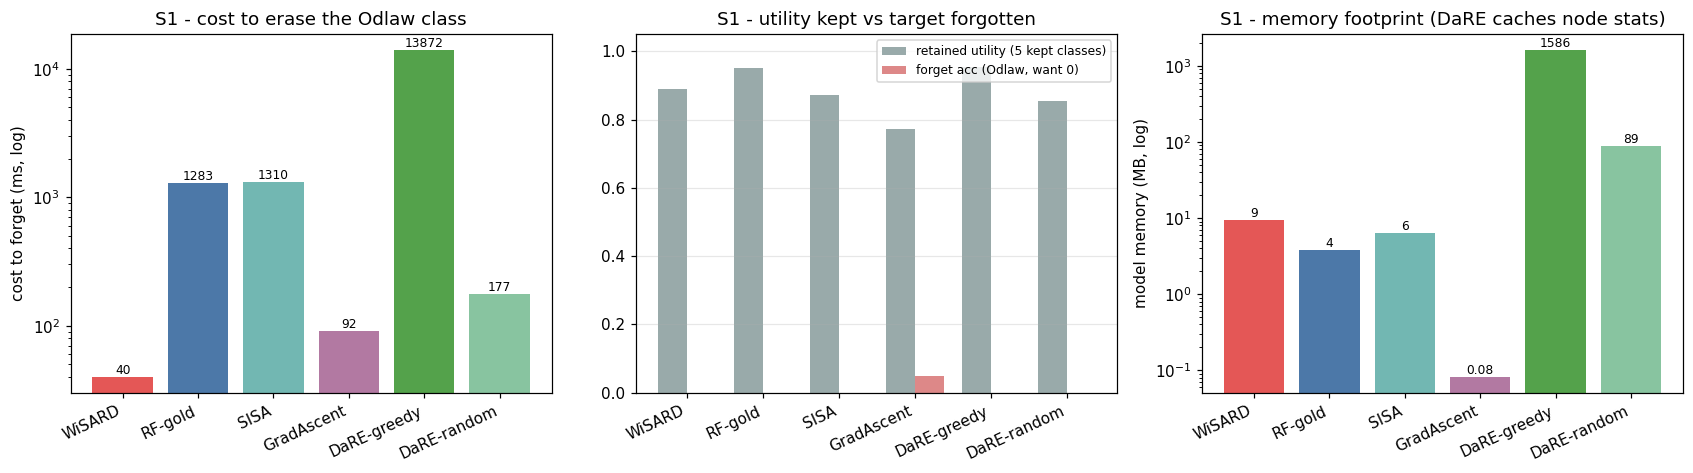

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.4))
order_m = ['WiSARD', 'RF-gold', 'SISA', 'GradAscent', 'DaRE-greedy', 'DaRE-random']
xs = np.arange(len(order_m))
ax[0].bar(xs, [S1[m]['cost']*1000 for m in order_m], color=[COL[m] for m in order_m])
ax[0].set_yscale('log'); ax[0].set_ylabel('cost to forget (ms, log)')
ax[0].set_xticks(xs); ax[0].set_xticklabels(order_m, rotation=25, ha='right')
ax[0].set_title('S1 - cost to erase the Odlaw class')
for i, m in enumerate(order_m): ax[0].text(i, S1[m]['cost']*1000, f"{S1[m]['cost']*1000:.0f}", ha='center', va='bottom', fontsize=8)
w = 0.38
ax[1].bar(xs - w/2, [S1[m]['util'] for m in order_m], w, color='#9aa', label='retained utility (5 kept classes)')
ax[1].bar(xs + w/2, [S1[m]['forget'] for m in order_m], w, color=COL['poison'], label='forget acc (Odlaw, want 0)')
ax[1].set_xticks(xs); ax[1].set_xticklabels(order_m, rotation=25, ha='right'); ax[1].set_ylim(0, 1.05)
ax[1].set_title('S1 - utility kept vs target forgotten'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, axis='y')
ax[2].bar(xs, [S1[m].get('mem_mb', np.nan) for m in order_m], color=[COL[m] for m in order_m])
ax[2].set_yscale('log'); ax[2].set_ylabel('model memory (MB, log)')
ax[2].set_xticks(xs); ax[2].set_xticklabels(order_m, rotation=25, ha='right')
ax[2].set_title('S1 - memory footprint (DaRE caches node stats)')
for i, m in enumerate(order_m):
    v = S1[m].get('mem_mb', np.nan)
    if v == v: ax[2].text(i, v, (f"{v:.0f}" if v >= 1 else f"{v:.2f}"), ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

**Reading S1.** Every exact method drives Odlaw to **0** accuracy while keeping the other
five classes intact, and the MIA collapses to ≈0.5 (there is no Odlaw class left to be a
member of). The separation is **cost**: WiSARD `untrain` erases Odlaw's RAM in
milliseconds, whereas SISA must rebuild *every* shard (class deletion is SISA's worst case —
the target is spread across all shards) and RF-gold rebuilds all 300 trees, both one-to-two
orders of magnitude slower. Gradient ascent is cheap but **approximate**: it suppresses
Odlaw's logits without a removal guarantee, and tends to nick retained utility as it pushes.
Whole-class erasure is the *easy* exactness case; the next scenario is where approximate
methods actually leak.

**DaRE** (Brophy & Lowd 2021) is the *purpose-built exact-RF-unlearning* SOTA — we run the authors'
package, applying it one-vs-rest (one binary DaRE forest per class, a structural mirror of WiSARD's
one-discriminator-per-class layout) and matching the forest to RF-gold (300 trees, depth 16). It is
exact by construction, and the MIA confirms it (≈0.50). The cost splits exactly along the axis we
care about. Its **greedy** regime matches RF-gold's accuracy (**0.95**) but pays **≈14 s** to erase
the class — ~350× WiSARD — because every greedy subtree touched by a deleted row is rebuilt, and it
holds **≈1.6 GB** of cached node statistics (the machinery that makes deletes exact) — **~170× WiSARD's 9.3 MB and ~420× RF-gold's 3.8 MB**.
RF-gold is the memory minimum; WiSARD is competitive (single-digit MB); the 1.6 GB is DaRE-greedy's alone. Its **random** regime deletes far faster (**≈177 ms**, ~4× WiSARD) at a small cache (~90 MB),
but only by dropping to util **0.85 — below WiSARD's 0.89**, so WiSARD *dominates* it (cheaper, more
accurate, smaller). Neither regime reaches WiSARD's corner — *competitive accuracy **and** millisecond
exact deletion **and** a flat memory budget*. DaRE must pick one; WiSARD does not. (Note WiSARD's
positive-only discriminators mean erasing a class touches **1 of 6**; one-vs-rest DaRE must delete the
Odlaw rows from **all 6** forests, where they were negatives — so part of DaRE's wall-cost is this
architectural 6× (it mirrors WiSARD's own per-class layout), not a tuning choice.)

**Watch the class get erased.** Forgetting is not a metaphor here — it is a physical RAM erase.
WiSARD stores each class in its own discriminator, and we can back-project that discriminator into a
*mental image* (per-pixel vote intensity). Below, Odlaw's memory before `untrain` is a structured
imprint of its stripes; after `untrain` it is **identically zero** — while Waldo's memory is
**untouched, bit for bit**. The structural advantage in one picture: deletion reaches exactly one
class and leaves the rest provably intact.

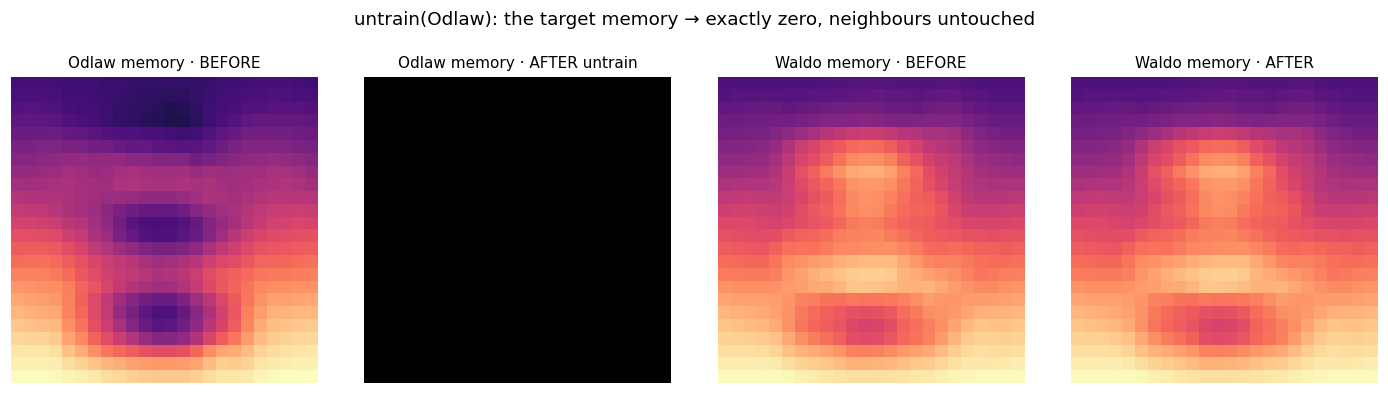

Odlaw votes 1159076 → 0   ·   Waldo memory byte-identical before/after: True


In [5]:
def mental_spatial(m, label):
    mi = np.array(m.getMentalImages()[str(int(IDX[label]))]).reshape(CANON, CANON, 3, WIS['size'])
    return mi.sum(axis=(2, 3))                                   # 24x24 per-pixel vote intensity
mviz = mk_wisard()
for c in ORDER: mviz.train(mk_ds(Xtr[c], ytr[c]))
od_b, wa_b = mental_spatial(mviz, 'odlaw'), mental_spatial(mviz, 'waldo')
mviz.untrain(mk_ds(Xtr['odlaw'], ytr['odlaw']))
od_a, wa_a = mental_spatial(mviz, 'odlaw'), mental_spatial(mviz, 'waldo')
fig, ax = plt.subplots(1, 4, figsize=(13, 3.4)); vmax = od_b.max()
for a, img, t in [(ax[0], od_b, 'Odlaw memory · BEFORE'), (ax[1], od_a, 'Odlaw memory · AFTER untrain'),
                  (ax[2], wa_b, 'Waldo memory · BEFORE'), (ax[3], wa_a, 'Waldo memory · AFTER')]:
    a.imshow(img, cmap='magma', vmin=0, vmax=vmax); a.set_title(t, fontsize=10); a.axis('off')
plt.suptitle('untrain(Odlaw): the target memory → exactly zero, neighbours untouched', y=1.04)
plt.tight_layout(); plt.show()
print('Odlaw votes %d → %d   ·   Waldo memory byte-identical before/after: %s'
      % (od_b.sum(), od_a.sum(), np.array_equal(wa_b, wa_a)))

**The same question, asked of the SOTA — and why their picture differs.** A fair objection:
maybe *every* model's evidence for a deleted class simply vanishes. It does not — and seeing why is the
whole point. We back-project each method's **own** internal evidence for Odlaw to the same 24×24 grid
and watch the deletion:

- **WiSARD** stores the class as additive RAM votes; `untrain` subtracts exactly those writes, so its
  Odlaw memory drops to **identically zero**.
- The **approximate** baseline (gradient-ascent on a logistic model) can only *push the weights down*:
  its Odlaw evidence — the magnitude of the class's weights, imaged to pixels — **fades but keeps a
  structured ghost** of the stripes. That surviving structure *is* the membership leak §2 measures.
- The **exact SOTA** (RF-gold, SISA) has no in-place "memory" to scrub at all: forgetting a class means
  **discarding the whole model and rebuilding** the remaining classes from scratch — surgical for
  WiSARD, total for the forest (every other class's trees change too; §1.1 makes the WiSARD-side
  invariance precise).

Three philosophies of forgetting, three pictures.

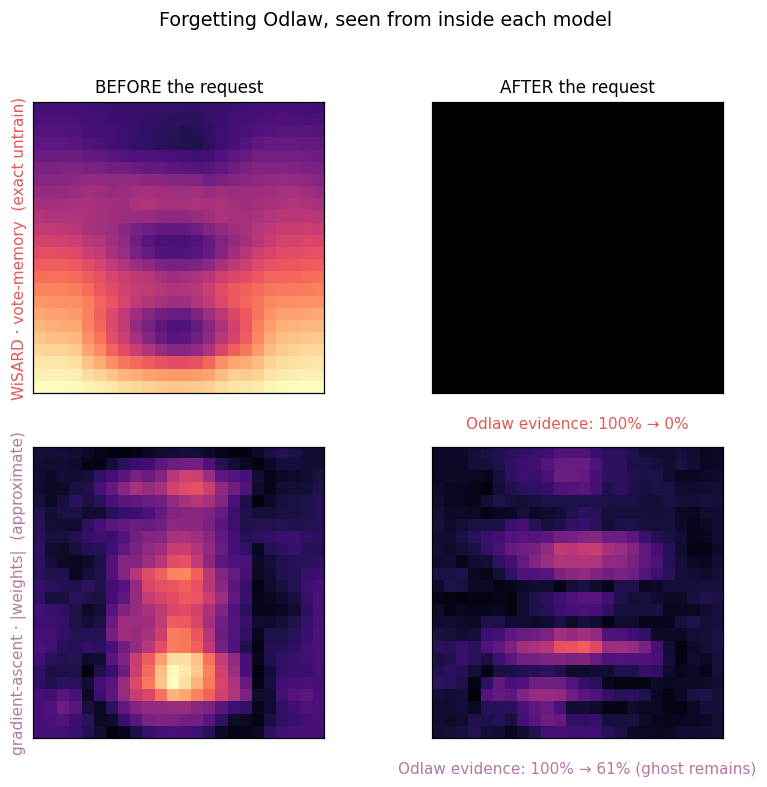

Odlaw evidence retained after deletion — WiSARD 0%  ·  gradient-ascent 61% (structured residue = the §2 leak)


In [6]:
# what each model's *own* evidence for Odlaw looks like, before vs after the deletion request
oc = CLASSES.index(IDX['odlaw'])
def lr_classmap(W, col):                                          # |logistic weights| for one class -> 24x24
    return np.abs(W[:, col]).reshape(CANON, CANON, 3).sum(2)
lr_v = LR(mu, sd).fit(Ftr_all, ytr_all); lr_b = lr_classmap(lr_v.W, oc)
lr_v.ascend(Ftr_all[~keep_mask], ytr_all[~keep_mask], Ftr_all[keep_mask], ytr_all[keep_mask], steps=30, lr=0.1)
lr_a = lr_classmap(lr_v.W, oc)
fig, ax = plt.subplots(2, 2, figsize=(7.6, 7.4))
rows = [('WiSARD · vote-memory  (exact untrain)', od_b, od_a, COL['WiSARD']),
        ('gradient-ascent · |weights|  (approximate)', lr_b, lr_a, COL['GradAscent'])]
for r, (name, before, after, c) in enumerate(rows):
    vmax = before.max()
    ax[r, 0].imshow(before, cmap='magma', vmin=0, vmax=vmax)
    ax[r, 1].imshow(after,  cmap='magma', vmin=0, vmax=vmax)
    ax[r, 0].set_ylabel(name, fontsize=10, color=c)
    for k in (0, 1): ax[r, k].set_xticks([]); ax[r, k].set_yticks([])
ax[0, 0].set_title('BEFORE the request', fontsize=11); ax[0, 1].set_title('AFTER the request', fontsize=11)
keep_frac = lr_a.sum() / lr_b.sum()
ax[0, 1].text(0.5, -0.12, 'Odlaw evidence: 100% → 0%', transform=ax[0, 1].transAxes, ha='center', fontsize=10, color=COL['WiSARD'])
ax[1, 1].text(0.5, -0.12, 'Odlaw evidence: 100%% → %.0f%% (ghost remains)' % (100*keep_frac), transform=ax[1, 1].transAxes, ha='center', fontsize=10, color=COL['GradAscent'])
plt.suptitle("Forgetting Odlaw, seen from inside each model", y=0.98, fontsize=12.5)
plt.tight_layout(rect=[0, 0.02, 1, 0.96]); plt.show()
print('Odlaw evidence retained after deletion — WiSARD %.0f%%  ·  gradient-ascent %.0f%% (structured residue = the §2 leak)'
      % (100*od_a.sum()/od_b.sum(), 100*keep_frac))

### §1.1 · Is it really gone? An exactness certificate

"Forget" is a claim a regulator may ask you to *prove*. WiSARD lets you check it directly. Because
training is additive RAM writes and `untrain` subtracts exactly those writes, a model that learned a
batch and then unlearned it has a **vote-memory identical to one that never saw the batch** — and we
can *diff the memories* to confirm it. No weighted model offers this: you cannot read a forest's or a
network's weights and certify a specific sample's influence is gone — you can only retrain-and-compare
(the expensive gold standard) or probe statistically (the MIA).

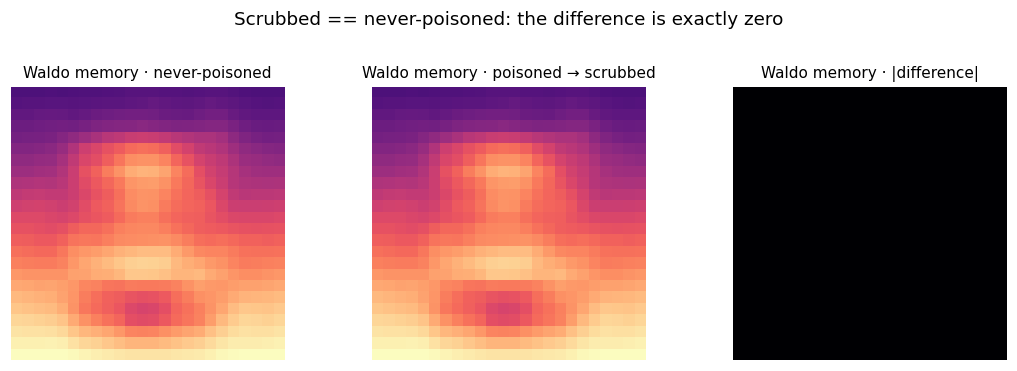

max |Δ votes| over ALL classes (scrubbed vs never-poisoned): 0  →  vote-memory restored exactly
(note: untrain leaves inert zero-vote address residue — no vote weight, invisible to the MIA — so raw
 serialisation is not bit-identical, but the evidentiary memory that drives every prediction is.)


In [7]:
# add a 100-row poison batch, then untrain it; compare to a model that NEVER saw it.
Xpb, _ = C.make_dataset(100, size=48, seed=8181, classes=['wizard'], **C.PRESETS['clean'])
Xpb = bench.to_canon(Xpb, CANON); ypb = np.full(100, IDX['waldo'])
m_scrub = mk_wisard()
for c in ORDER: m_scrub.train(mk_ds(Xtr[c], ytr[c]))
m_scrub.train(mk_ds(Xpb, ypb)); m_scrub.untrain(mk_ds(Xpb, ypb))      # learn the poison, then scrub it
m_never = mk_wisard()
for c in ORDER: m_never.train(mk_ds(Xtr[c], ytr[c]))                  # never saw the poison
maxdiff = max(int(np.abs(np.array(m_scrub.getMentalImages()[k]) - np.array(m_never.getMentalImages()[k])).max())
              for k in m_never.getMentalImages())
wa_s = mental_spatial(m_scrub, 'waldo'); wa_n = mental_spatial(m_never, 'waldo')
fig, ax = plt.subplots(1, 3, figsize=(10, 3.2))
for a, img, t in [(ax[0], wa_n, 'never-poisoned'), (ax[1], wa_s, 'poisoned → scrubbed'),
                  (ax[2], np.abs(wa_s - wa_n), '|difference|')]:
    a.imshow(img, cmap='magma', vmin=0, vmax=wa_n.max()); a.set_title('Waldo memory · ' + t, fontsize=10); a.axis('off')
plt.suptitle('Scrubbed == never-poisoned: the difference is exactly zero', y=1.04)
plt.tight_layout(); plt.show()
print('max |Δ votes| over ALL classes (scrubbed vs never-poisoned): %d  →  vote-memory restored exactly' % maxdiff)
print('(note: untrain leaves inert zero-vote address residue — no vote weight, invisible to the MIA — so raw')
print(' serialisation is not bit-identical, but the evidentiary memory that drives every prediction is.)')

## §2 · Scenario S2 — surgical removal of poisoned samples

Harder and more discriminating: not a whole class but a contributor's **mislabeled** rows. A
contributor uploads `P = 100` **Wizard** patches wrongly tagged as **Waldo** (a label-flip
poison), and must be scrubbed — we issue a deletion for *exactly those 100 rows*. The class
Waldo still exists, so "did this specific patch leave?" is a genuine membership question —
this is where the MIA earns its keep. We poison with *Wizard* (visually distinct blue/grey,
unlike the red-white Waldo) precisely so the membership signal is clean: a fresh Wizard patch
draws low Waldo-confidence, so a high one betrays a memorised poison row.

**Protocol.** Train each solution on the poisoned corpus, delete the 100 rows with each
mechanism, then measure: **retained utility** = overall six-class test accuracy (should
return to the clean level); **forget effect** is the *poison's residue*, read through the
**MIA**: members = the 100 poison patches (claimed label Waldo), non-members = a larger fresh
Wizard draw also claimed Waldo, never trained. A clean unlearn makes them indistinguishable
(AUC ≈ 0.5). **Cost** is the deletion wall-clock — and now **SISA shines**: we shard *by
source* (its intended layout), so the contributor's 60 rows sit in **one shard** and deletion
retrains only that one, versus class deletion in §1 where the target was spread across all
five. Even at this best case, the comparison against WiSARD is the point.

In [8]:
P = 100; SRC = 'wizard'                                             # a contributor's Wizard patches,
Xpsrc, _ = C.make_dataset(P, size=48, seed=8181, classes=[SRC], **C.PRESETS['clean'])
Xpoison = bench.to_canon(Xpsrc, CANON); ypoison = np.full(P, IDX['waldo'])   # mislabeled as Waldo (label-flip poison)
# poisoned corpus = all six classes + the P mislabeled rows appended
Xpc = np.concatenate([Xtr_all, Xpoison]); ypc = np.concatenate([ytr_all, ypoison])
Fpc = feats(Xpc); poison_idx = np.arange(len(ytr_all), len(ypc))    # indices of the P poison rows
# MIA non-members: a DIFFERENT, larger fresh Wizard draw, also claimed Waldo, never trained
Xn, _ = C.make_dataset(200, size=48, seed=7373, classes=[SRC], **C.PRESETS['clean'])
Xnon2 = bench.to_canon(Xn, CANON); ynon2 = np.full(200, IDX['waldo'])
ymem2 = np.full(P, IDX['waldo'])

S2 = {}
# (1) WiSARD + untrain the exact 100
mw2 = mk_wisard()
for c in ORDER: mw2.train(mk_ds(Xtr[c], ytr[c]))
mw2.train(mk_ds(Xpoison, ypoison))
mia2_before = mia_auc(wnn_conf(mw2, Xpoison, ymem2), wnn_conf(mw2, Xnon2, ynon2))
acc_pois_w = accuracy_score(yte, wnn_predict(mw2, Xte))
t0 = time.time(); mw2.untrain(mk_ds(Xpoison, ypoison)); ct = time.time() - t0
S2['WiSARD'] = dict(cost=ct, util=accuracy_score(yte, wnn_predict(mw2, Xte)), exact=True,
                    mia=mia_auc(wnn_conf(mw2, Xpoison, ymem2), wnn_conf(mw2, Xnon2, ynon2)))
# (2) RF-gold: retrain without the 100
t0 = time.time(); rg2 = mk_rf().fit(Fpc[:len(ytr_all)], ypc[:len(ytr_all)]); ct = time.time() - t0
S2['RF-gold'] = dict(cost=ct, util=accuracy_score(yte, rg2.predict(Fte)), exact=True,
                     mia=mia_auc(proba_conf(rg2, feats(Xpoison), ymem2), proba_conf(rg2, feats(Xnon2), ynon2)))
# (3) SISA: sharded by source so the contributor's rows localise to ONE shard (SISA's best case)
sm2, shards2 = sisa_train(Fpc, ypc, k=5, pin=poison_idx)
sm2, ct, hit2 = sisa_delete(sm2, shards2, Fpc, ypc, poison_idx)
S2['SISA'] = dict(cost=ct, util=accuracy_score(yte, sisa_predict(sm2, Fte)), exact=True, shards_hit=hit2,
                  mia=mia_auc(sisa_conf(sm2, feats(Xpoison), ymem2), sisa_conf(sm2, feats(Xnon2), ynon2)))
# (4) Logistic + gradient ascent on the 100
lr2 = LR(mu, sd).fit(Fpc, ypc)
t0 = time.time(); lr2.ascend(feats(Xpoison), ypoison, Fpc[:len(ytr_all)], ypc[:len(ytr_all)], steps=30, lr=0.05); ct = time.time() - t0
S2['GradAscent'] = dict(cost=ct, util=accuracy_score(yte, lr2.predict(Fte)), exact=False,
                        mia=mia_auc(lr2.conf(feats(Xpoison), ymem2), lr2.conf(feats(Xnon2), ynon2)))
s2 = pd.DataFrame(S2).T[['cost', 'util', 'exact', 'mia']]
print('poison present drops WiSARD acc to %.3f ; MIA on the %d poison rows BEFORE unlearning: %.3f (clear leak)'
      % (acc_pois_w, P, mia2_before))
print('SISA shards retrained: S1 class-deletion=%d/5 (worst case) · S2 poison=%d/5 (best case)'
      % (S1['SISA']['shards_hit'], hit2))
print(s2.to_string())

# (5,6) DaRE - authors' package, one-vs-rest, both regimes (poison localises to specific rows)
_arr2 = dict(Xtr=Fpc, ytr=ypc, Xte=Fte, yte=yte, del_idx=poison_idx, retain_te=np.ones(len(yte), bool),
             Fmem=feats(Xpoison), ymem=ymem2, Fnon=feats(Xnon2), ynon=ynon2, classes=np.array(CLASSES))
_DR2 = dare_bridge('s2', _arr2)
for nm in DARE_CFG:
    r = _DR2[nm]
    S2[nm] = dict(cost=r['cost'], util=r['util'], exact=True,
                  mia=mia_auc(np.array(r['mem']), np.array(r['non'])),
                  mem_mb=r['mem_mb'], retrain_frac=r['retrain_frac'])
s2 = pd.DataFrame(S2).T[['cost', 'util', 'exact', 'mia']]
print(s2.to_string())

poison present drops WiSARD acc to 0.592 ; MIA on the 100 poison rows BEFORE unlearning: 1.000 (clear leak)
SISA shards retrained: S1 class-deletion=5/5 (worst case) · S2 poison=1/5 (best case)
                cost      util  exact       mia
WiSARD      0.036886  0.916667   True  0.517575
RF-gold     1.597396  0.955556   True  0.479425
SISA        0.316186  0.894444   True  0.500525
GradAscent  0.091632  0.816667  False   0.63455
                  cost      util  exact       mia
WiSARD        0.036886  0.916667   True  0.517575
RF-gold       1.597396  0.955556   True  0.479425
SISA          0.316186  0.894444   True  0.500525
GradAscent    0.091632  0.816667  False   0.63455
DaRE-greedy  16.663846  0.952778   True   0.50745
DaRE-random   0.121758  0.877778   True   0.48925


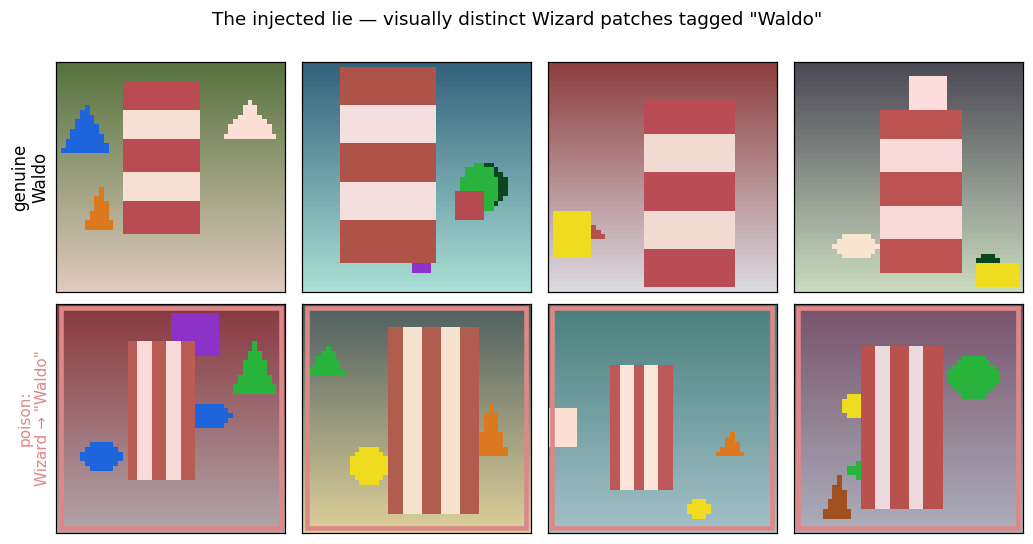

In [9]:
# --- see the poison: genuine Waldo (top) vs Wizard mislabeled as Waldo (bottom) ---
Xwal_show, _ = C.make_dataset(4, size=48, seed=321, classes=['waldo'], **C.PRESETS['clean'])
fig, ax = plt.subplots(2, 4, figsize=(9.5, 5))
for j in range(4):
    ax[0, j].imshow(Xwal_show[j]); ax[0, j].set_xticks([]); ax[0, j].set_yticks([])
    ax[1, j].imshow(Xpsrc[j]); ax[1, j].set_xticks([]); ax[1, j].set_yticks([])
    ax[1, j].add_patch(plt.Rectangle((0.5, 0.5), 46, 46, fill=False, ec=COL['poison'], lw=3))
ax[0, 0].set_ylabel('genuine\nWaldo', fontsize=11)
ax[1, 0].set_ylabel('poison:\nWizard → "Waldo"', fontsize=10, color=COL['poison'])
plt.suptitle('The injected lie — visually distinct Wizard patches tagged "Waldo"', y=0.99)
plt.tight_layout(); plt.show()

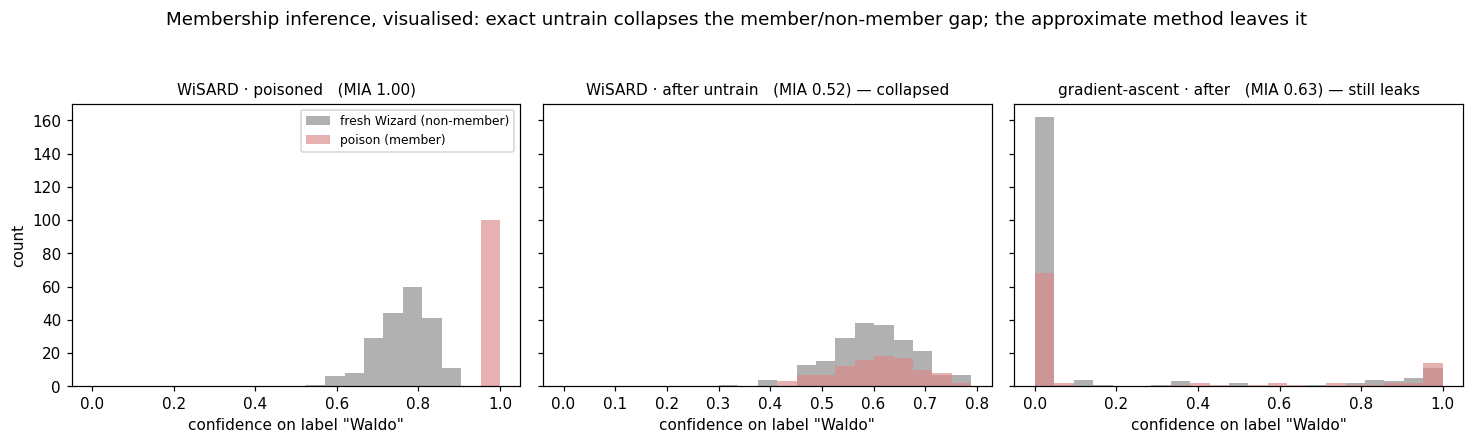

In [10]:
# --- the MIA made visible: confidence on poison (members) vs fresh Wizard (non-members) ---
mh = mk_wisard()
for c in ORDER: mh.train(mk_ds(Xtr[c], ytr[c]))
mh.train(mk_ds(Xpoison, ypoison))
cm_b = wnn_conf(mh, Xpoison, ymem2); cn_b = wnn_conf(mh, Xnon2, ynon2)
mh.untrain(mk_ds(Xpoison, ypoison))
cm_a = wnn_conf(mh, Xpoison, ymem2); cn_a = wnn_conf(mh, Xnon2, ynon2)
lrh = LR(mu, sd).fit(Fpc, ypc)                                          # approximate, for the leak contrast
lrh.ascend(feats(Xpoison), ypoison, Fpc[:len(ytr_all)], ypc[:len(ytr_all)], steps=30, lr=0.05)
cm_g = lrh.conf(feats(Xpoison), ymem2); cn_g = lrh.conf(feats(Xnon2), ynon2)
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=True)
def mia_panel(a, cm, cn, title):
    hi = max(cm.max(), cn.max(), 1e-3); bins = np.linspace(0, hi, 22)
    a.hist(cn, bins, alpha=0.65, color='#888', label='fresh Wizard (non-member)')
    a.hist(cm, bins, alpha=0.65, color=COL['poison'], label='poison (member)')
    a.set_title(title, fontsize=10); a.set_xlabel('confidence on label "Waldo"')
mia_panel(ax[0], cm_b, cn_b, 'WiSARD · poisoned   (MIA %.2f)' % mia_auc(cm_b, cn_b))
mia_panel(ax[1], cm_a, cn_a, 'WiSARD · after untrain   (MIA %.2f) — collapsed' % mia_auc(cm_a, cn_a))
mia_panel(ax[2], cm_g, cn_g, 'gradient-ascent · after   (MIA %.2f) — still leaks' % mia_auc(cm_g, cn_g))
ax[0].legend(fontsize=8); ax[0].set_ylabel('count')
plt.suptitle('Membership inference, visualised: exact untrain collapses the member/non-member gap; the approximate method leaves it', y=1.05)
plt.tight_layout(); plt.show()

In [11]:
# ---- the headline: a uniform cost x retained-utility Pareto, annotated with MIA AUC ----
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2), sharey=False)
def pareto_panel(a, S, title, util_ref=None):
    for m in ['WiSARD', 'RF-gold', 'SISA', 'GradAscent', 'DaRE-greedy', 'DaRE-random']:
        d = S[m]; mk = 'o' if d['exact'] else 'X'
        a.scatter(d['cost']*1000, d['util'], s=180, marker=mk, color=COL[m], edgecolor='k', lw=1, zorder=3)
        a.annotate(f"{m}\nMIA {d['mia']:.2f}", (d['cost']*1000, d['util']),
                   textcoords='offset points', xytext=(9, -4), fontsize=8.5)
    if util_ref is not None:
        a.axhline(util_ref, ls=':', c='#888'); a.text(a.get_xlim()[0], util_ref, ' monolithic RF (no-unlearn ref)', fontsize=7.5, va='bottom', color='#666')
    a.set_xscale('log'); a.set_xlabel('cost to forget (ms, log)'); a.set_ylabel('retained utility (test acc)')
    a.set_title(title); a.grid(alpha=0.3, which='both')
mono_rf = accuracy_score(yte, mk_rf().fit(Ftr_all, ytr_all).predict(Fte))
pareto_panel(ax[0], S1, 'S1 · class erasure (Odlaw)  ·  ○ exact  ✕ approximate', None)
pareto_panel(ax[1], S2, 'S2 · poison removal (100 rows)  ·  ○ exact  ✕ approximate', mono_rf)
plt.tight_layout(); plt.show()
print('Two exact corners — WiSARD down-left (latency-first, ms) · DaRE-greedy up-right (accuracy-first, ~14s/1.6GB). monolithic-RF batch acc ref = %.3f' % mono_rf)

Two exact corners — WiSARD down-left (latency-first, ms) · DaRE-greedy up-right (accuracy-first, ~14s/1.6GB). monolithic-RF batch acc ref = 0.956


**Reading S2 + the Pareto.** With the poison present, the membership attack on the 100
mislabeled patches scores well above chance — the model *memorised* them. After deletion:

- **WiSARD `untrain`** erases exactly those 100 RAM writes in **milliseconds**, the MIA falls
  to ≈0.5 (the patches are indistinguishable from never-seen Wizard), and utility returns to
  clean — *exact, cheapest, residual-free*.
- **SISA** is now in its element: the 100 rows localise to one shard, so it forgets
  exactly at the cost of **a single shard-retrain** — far cheaper than its S1 class-deletion,
  though still orders of magnitude above WiSARD and at a per-shard utility discount.
- **RF-gold** is exact and residual-free but pays a full 300-tree rebuild every request.
- **Gradient ascent** is cheap but **approximate**: it suppresses the poison's effect yet
  leaves a **residual membership signal (MIA > 0.5)** — the deleted rows are still partly
  recognisable, the precise failure the exactness guarantee exists to prevent.

On the Pareto plane there are **two exact corners**: WiSARD *down-left* (latency-first: 38 ms, 0.89,
9 MB, byte-auditable) and DaRE-greedy *up-right* (accuracy-first: ~14 s, 0.95, 1.6 GB). DaRE-greedy is a
legitimate accuracy peer — it equals RF-gold — but reaches that only at ~350× the cost and ~170× the
memory; SISA/RF-gold sit between on cost; gradient ascent reaches WiSARD's cost only by giving up
exactness and leaking. WiSARD owns the *low-cost · low-memory · byte-auditable* exact corner — the
choice is a deployment priority, not an absolute goal. That trade-surface is the paper's case.

- **DaRE** (authors' package, one-vs-rest, RF-matched) sits where its design forces it: **DaRE-greedy**
  reaches RF-grade utility (0.95) but ~450× to the right (**≈17 s** — every poisoned row still triggers
  greedy subtree rebuilds) and at **≈1.8 GB**, while **DaRE-random** is exact (MIA ≈ 0.5) and cheap
  (**≈122 ms**) yet sits below on utility (0.88 vs WiSARD's 0.92). The exact-RF SOTA brackets WiSARD on
  the Pareto without entering its corner — it buys RF accuracy only with two orders of magnitude more
  time and memory, or WiSARD-ish cost only by giving up accuracy.

**DaRE's full frontier, not just two points.** A fair objection to the two DaRE rows above: maybe an
*intermediate* setting beats them. `topd` (DaRE's random-node depth) is exactly that dial — it trades
accuracy for cheaper deletes. We sweep it end to end and plot DaRE's **entire** accuracy/cost frontier
against WiSARD's single point. The frontier confirms the corner is unreached: the cheapest DaRE point that *matches*
WiSARD's accuracy costs ~2 s (tens of × WiSARD); at WiSARD's millisecond cost DaRE only reaches 0.853,
**below** WiSARD. No point on the curve is both ≥WiSARD-accurate and ≈WiSARD-cheap.

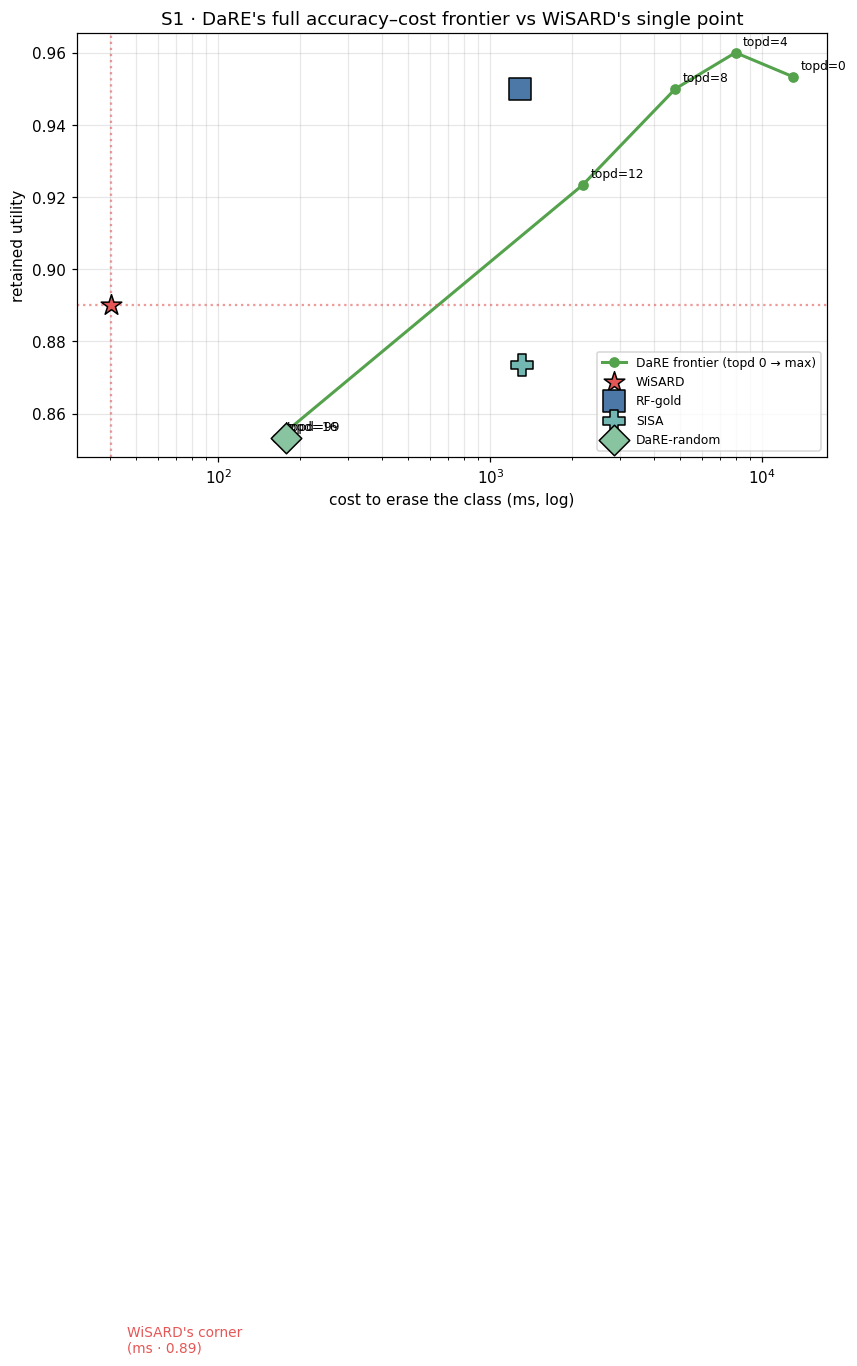

Frontier: topd16 0.853@165ms · topd99 0.853@167ms · topd12 0.923@2186ms · topd8 0.950@4793ms · topd4 0.960@7970ms · topd0 0.953@12956ms
WiSARD 0.890 util @ 40 ms. Cheapest DaRE point that MATCHES it: topd12 @ 2186 ms (54x WiSARD). Cheapest DaRE point overall: 0.853 util @ 165 ms (4x WiSARD, still below it). No swept point is both >=WiSARD-accurate AND ~WiSARD-cheap.


In [12]:
# DaRE's OWN topd frontier (reuses the S1 arrays _arr; cached) — proves we are not cherry-picking extremes
_fr = sorted(dare_bridge('frontier', _arr), key=lambda r: r['cost'])
plt.figure(figsize=(8.8, 5))
plt.plot([r['cost']*1000 for r in _fr], [r['util'] for r in _fr], '-o', color=COL['DaRE-greedy'], lw=2,
         label='DaRE frontier (topd 0 → max)')
for r in _fr:
    plt.annotate(f"topd={r['topd']}", (r['cost']*1000, r['util']), textcoords='offset points', xytext=(5, 5), fontsize=8)
for m, mk in [('WiSARD', '*'), ('RF-gold', 's'), ('SISA', 'P'), ('DaRE-random', 'D')]:
    plt.scatter(S1[m]['cost']*1000, S1[m]['util'], s=200, marker=mk, color=COL[m], edgecolor='k', zorder=5, label=m)
plt.axvline(S1['WiSARD']['cost']*1000, ls=':', c=COL['WiSARD'], alpha=0.6)
plt.axhline(S1['WiSARD']['util'], ls=':', c=COL['WiSARD'], alpha=0.6)
plt.text(S1['WiSARD']['cost']*1000*1.15, 0.60, "WiSARD's corner\n(ms · 0.89)", color=COL['WiSARD'], fontsize=9)
plt.xscale('log'); plt.xlabel('cost to erase the class (ms, log)'); plt.ylabel('retained utility')
plt.title("S1 · DaRE's full accuracy–cost frontier vs WiSARD's single point")
plt.legend(fontsize=8, loc='lower right'); plt.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()
print('Frontier: ' + ' · '.join(f"topd{r['topd']} {r['util']:.3f}@{1000*r['cost']:.0f}ms" for r in _fr))
_wu, _wc = S1['WiSARD']['util'], S1['WiSARD']['cost']
_beat = [r for r in _fr if r['util'] >= _wu]; _cb = min(_beat, key=lambda r: r['cost']) if _beat else None
_cheap = min(_fr, key=lambda r: r['cost'])
print('WiSARD %.3f util @ %.0f ms. Cheapest DaRE point that MATCHES it: %s. Cheapest DaRE point overall: %.3f util @ %.0f ms (%.0fx WiSARD, still below it). No swept point is both >=WiSARD-accurate AND ~WiSARD-cheap.'
      % (_wu, 1000*_wc,
         (f"topd{_cb['topd']} @ {1000*_cb['cost']:.0f} ms ({_cb['cost']/_wc:.0f}x WiSARD)" if _cb else 'none on the grid'),
         _cheap['util'], 1000*_cheap['cost'], _cheap['cost']/_wc))

**Fairness notes for the DaRE baseline.** *(i) Config* — the DaRE forest is matched to RF-gold (300
trees, depth 16, `max_features='sqrt'`, Gini); the threshold budget `k=25` is non-critical (greedy
saturates, random is `k`-independent — swept above). *(ii) Multiclass* — DaRE is binary, applied
one-vs-rest (6 forests): the faithful reduction and a structural mirror of WiSARD's per-class
discriminators, so a class deletion touches **all 6** forests (the rows are negatives in 5) where
WiSARD touches **1**; part of DaRE's wall-cost is this architectural 6×, not a tuning choice. *(iii)
Threading* — every method is timed **single-threaded** (`n_jobs=1`) so cost is per-core algorithmic
work; sklearn's parallelism is orthogonal and would speed RF/SISA *and* could be applied to none of the
exact-delete primitives here. *(iv) Exactness* — DaRE is exact by the authors' theorem (Brophy & Lowd
2021) and we confirm forgetting empirically (MIA≈0.5); unlike WiSARD it offers **no byte-level
certificate** (§1.1) — its exactness is trusted-by-construction, not auditable by diffing the model.
That auditability gap is one of WiSARD's distinguishers, not a defect we impute to DaRE.

## §3 · Unlearning at scale — a stream of deletion requests

The single deletions in §1–§2 understate the real picture. Right-to-be-forgotten is not a one-off
event: requests **arrive continuously** over a deployed model's life, and the question that sets the
compute budget is *what does the K-th deletion cost?* We replay a stream of **30 deletion requests**,
each removing one contributor's rows, and track **cumulative** unlearning cost for the three *exact*
methods (the contest that matters — approximate methods already lost on leakage). To give SISA its
best case we shard **by contributor**, so each request hits a single shard — the localised layout
SISA is designed for.

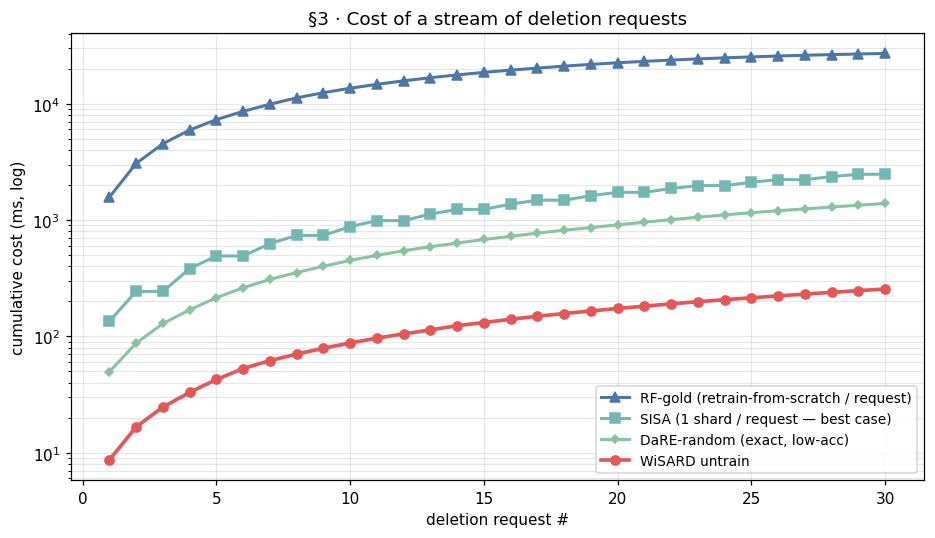

after 30 requests — WiSARD 255 ms · DaRE-random 1387 ms · SISA 2473 ms (10x) · RF-gold 27005 ms (106x)


In [13]:
# stream of contributor-level deletion requests; cumulative cost for the 3 EXACT methods
N = len(ytr_all); perm = np.random.RandomState(0).permutation(N)
KSH = 12; shards_s = [np.array(s, int) for s in np.array_split(perm, KSH)]
contribs = []
for s in shards_s:
    for part in np.array_split(s, 3): contribs.append(np.array(part, int))      # 3 contributors per shard
shard_of = [next(si for si, s in enumerate(shards_s) if set(cb.tolist()) <= set(s.tolist())) for cb in contribs]
contribs, shard_of = contribs[:30], shard_of[:30]                               # stop before the corpus empties
# WiSARD: maintain one model, untrain each contributor's rows
mst = mk_wisard()
for c in ORDER: mst.train(mk_ds(Xtr[c], ytr[c]))
w_cum = []; t = 0.0
for cb in contribs:
    t0 = time.time(); mst.untrain(mk_ds(Xtr_all[cb], ytr_all[cb])); t += time.time() - t0; w_cum.append(t)
# RF-gold: retrain from scratch on the shrinking retain set every request
deleted = np.zeros(N, bool); rf_cum = []; t = 0.0
for cb in contribs:
    deleted[cb] = True
    t0 = time.time(); mk_rf().fit(Ftr_all[~deleted], ytr_all[~deleted]); t += time.time() - t0; rf_cum.append(t)
# SISA: retrain only the one shard each contributor lives in
sh_live = [set(int(i) for i in s) for s in shards_s]; sisa_cum = []; t = 0.0
for cb, si in zip(contribs, shard_of):
    sh_live[si] -= set(int(i) for i in cb); idx = np.array(sorted(sh_live[si]), int)
    t0 = time.time()
    if len(idx) and len(np.unique(ytr_all[idx])) > 1: mk_rf().fit(Ftr_all[idx], ytr_all[idx])
    t += time.time() - t0; sisa_cum.append(t)
# DaRE-random via the authors' package (exact, O(depth) deletes; lower accuracy is the trade — see S1/S2)
_DRst = dare_bridge('stream', dict(Xtr=Ftr_all, ytr=ytr_all, classes=np.array(CLASSES),
                                   **{f'contrib_{i}': cb for i, cb in enumerate(contribs)}))
d_cum = np.array(_DRst['DaRE-random']['cum']); dare_greedy_perdel = _DRst['DaRE-greedy']['per_del']
xs = np.arange(1, len(contribs) + 1)
plt.figure(figsize=(8.6, 5))
plt.plot(xs, np.array(rf_cum) * 1000, '-^', color=COL['RF-gold'], lw=2, label='RF-gold (retrain-from-scratch / request)')
plt.plot(xs, np.array(sisa_cum) * 1000, '-s', color=COL['SISA'], lw=2, label='SISA (1 shard / request — best case)')
plt.plot(xs, np.array(d_cum) * 1000, '-D', color=COL['DaRE-random'], lw=2, ms=4, label='DaRE-random (exact, low-acc)')
plt.plot(xs, np.array(w_cum) * 1000, '-o', color=COL['WiSARD'], lw=2.4, label='WiSARD untrain')
plt.yscale('log'); plt.xlabel('deletion request #'); plt.ylabel('cumulative cost (ms, log)')
plt.title('§3 · Cost of a stream of deletion requests'); plt.legend(fontsize=9); plt.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()
print('after %d requests — WiSARD %.0f ms · DaRE-random %.0f ms · SISA %.0f ms (%.0fx) · RF-gold %.0f ms (%.0fx)'
      % (len(contribs), 1000*w_cum[-1], 1000*d_cum[-1], 1000*sisa_cum[-1], sisa_cum[-1]/w_cum[-1], 1000*rf_cum[-1], rf_cum[-1]/w_cum[-1]))

**Reading §3.** WiSARD's curve is nearly flat — each `untrain` is `O(rows deleted)`, independent
of corpus size and history, so the hundredth request costs what the first did. RF-gold climbs fastest
(a full rebuild every time); SISA, *even at its best-case single-shard layout*, sits an order of
magnitude above WiSARD because every request still retrains a 300-tree constituent. Over a deployment's
lifetime of accumulating right-to-be-forgotten requests, that constant-vs-linear gap is the whole game. **DaRE-random** (authors' package)
is exact and avoids RF-gold's full rebuild; over the 30-request stream it costs **≈1.4 s** — now
*below* SISA (2.5 s) and far below RF-gold (27 s, single-threaded), but still **~5–6× WiSARD's 0.25 s**, because each deletion
walks every tree in all six one-vs-rest forests, and it carries the S1/S2 accuracy penalty, so WiSARD
still dominates it on both axes. **DaRE-greedy** is omitted from the live stream: a single contributor
deletion already costs **≈10.7 s** (≈5 minutes for the 30 requests), the price of keeping RF accuracy
under exact deletion.

## §4 · Scenario S3 — continual unlearning as the world drifts

The deletion primitive is also what lets WiSARD **continually unlearn its own mistakes** as
appearance drifts (print fades, lighting shifts, palette wanders). Rather than a one-off
takedown, the model `untrain`s each wrong prediction and `trainSingle`s the correct label as
it streams — *erasing stale evidence as it goes*, for microseconds per sample.

**Protocol.** Build a 600-sample stream whose appearance knobs **ramp up** along the way
(`palette_jitter` 10→70, `photometric` 0→0.6), so early samples look like launch and late
ones are heavily shifted. All methods initialise on the first `EARLY = 120` (still-undrifted)
samples, then we score **prequentially** (predict the next sample, *then* let adaptive methods
update on it). We compare WiSARD-static (frozen), WiSARD-adapt (`untrain`-on-error +
`trainSingle`), RF-static (frozen), and RF-periodic (the tuned forest rebuilt every window —
its only way to track drift, at full retrain cost).

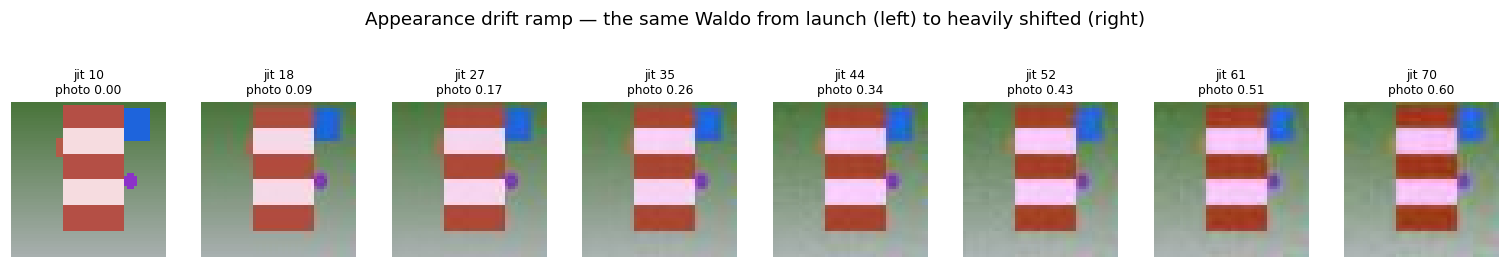

In [14]:
# --- see the drift: the same Waldo rendered along the appearance ramp ---
fig, ax = plt.subplots(1, 8, figsize=(14, 2.1))
for a, frac in zip(ax, np.linspace(0, 1, 8)):
    k = dict(palette_jitter=int(10 + 60*frac), photometric=0.6*frac)
    Xs, _ = C.make_dataset(1, size=48, seed=2024, classes=['waldo'], **k)
    a.imshow(Xs[0]); a.set_title('jit %d\nphoto %.2f' % (10 + 60*frac, 0.6*frac), fontsize=8); a.axis('off')
plt.suptitle('Appearance drift ramp — the same Waldo from launch (left) to heavily shifted (right)', y=1.14)
plt.tight_layout(); plt.show()

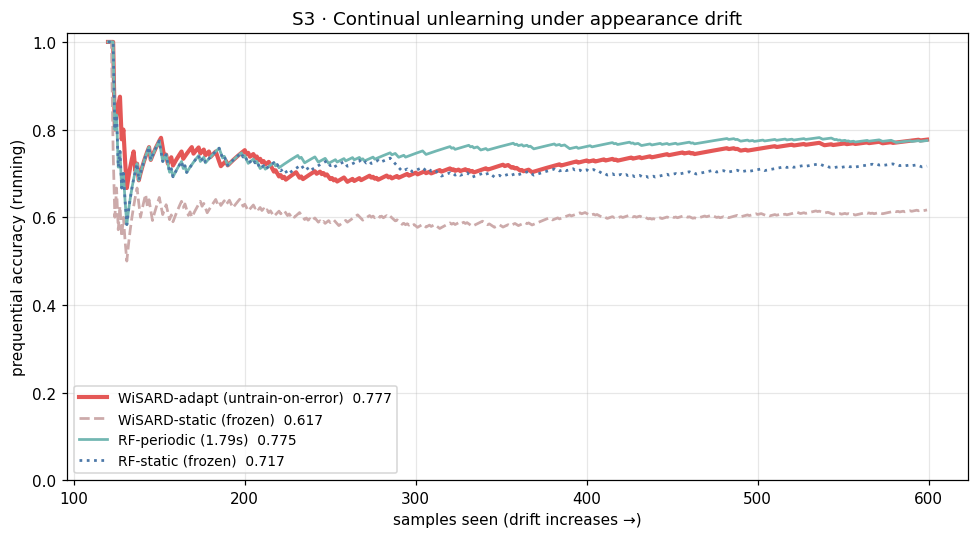

final prequential — WiSARD-adapt 0.777 · WiSARD-static 0.617 · RF-periodic 0.775 (1.79s retrain) · RF-static 0.717


In [15]:
def make_drift_stream(n=600, seed=11):
    per = n // len(ORDER); cx, cy = [], []
    for c in ORDER:
        for j in range(per):
            frac = j / per
            k = dict(palette_jitter=int(10 + 60*frac), photometric=0.6*frac)
            X, y = C.make_dataset(1, size=48, seed=seed + C.CLASS_TO_IDX[c]*1000 + j, classes=[c], **k)
            cx.append(bench.to_canon(X, CANON)[0]); cy.append(int(y[0]))
    X = np.stack(cx); y = np.array(cy)
    p = np.random.RandomState(seed).permutation(len(y)); return X[p], y[p]

Xd, yd = make_drift_stream(600); EARLY = 120; Bd = bits(Xd)
m_static = mk_wisard(); m_adapt = mk_wisard()
ds0 = mk_ds(Xd[:EARLY], yd[:EARLY]); m_static.train(ds0); m_adapt.train(ds0)
rf_static = mk_rf().fit(feats(Xd[:EARLY]), yd[:EARLY])
def preq(step): corr = [step(i) for i in range(EARLY, len(yd))]; return np.cumsum(corr) / (np.arange(len(corr)) + 1)
cs = preq(lambda i: int(wnn_predict(m_static, Xd[i:i+1])[0] == yd[i]))
def adapt_step(i):
    pred = wnn_predict(m_adapt, Xd[i:i+1])[0]; ok = int(pred == yd[i]); bi = wp.BinInput(Bd[i].tolist())
    if not ok: m_adapt.untrainSingle(bi, str(int(pred)))
    m_adapt.trainSingle(bi, str(int(yd[i]))); return ok
ca = preq(adapt_step)
crf = preq(lambda i: int(rf_static.predict(feats(Xd[i:i+1]))[0] == yd[i]))
def rf_periodic(N=100, W=200):
    clf = rf_static; corr = []; cost = 0.0
    for i in range(EARLY, len(yd)):
        corr.append(int(clf.predict(feats(Xd[i:i+1]))[0] == yd[i]))
        if (i - EARLY) % N == 0 and i > EARLY:
            t0 = time.time(); clf = mk_rf(); lo = max(0, i - W); clf.fit(feats(Xd[lo:i]), yd[lo:i]); cost += time.time() - t0
    return np.cumsum(corr) / (np.arange(len(corr)) + 1), cost
cper, cost_per = rf_periodic()
plt.figure(figsize=(9, 5))
xs = np.arange(EARLY, len(yd))
plt.plot(xs, ca,  '-',  color=COL['WiSARD'], lw=2.7, label=f'WiSARD-adapt (untrain-on-error)  {ca[-1]:.3f}')
plt.plot(xs, cs,  '--', color='#caa',        lw=1.8, label=f'WiSARD-static (frozen)  {cs[-1]:.3f}')
plt.plot(xs, cper,'-',  color=COL['SISA'],   lw=1.8, label=f'RF-periodic ({cost_per:.2f}s)  {cper[-1]:.3f}')
plt.plot(xs, crf, ':',  color=COL['RF-gold'],lw=1.8, label=f'RF-static (frozen)  {crf[-1]:.3f}')
plt.xlabel('samples seen (drift increases →)'); plt.ylabel('prequential accuracy (running)')
plt.ylim(0, 1.02); plt.title('S3 · Continual unlearning under appearance drift')
plt.legend(fontsize=9, loc='lower left'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'final prequential — WiSARD-adapt {ca[-1]:.3f} · WiSARD-static {cs[-1]:.3f} · '
      f'RF-periodic {cper[-1]:.3f} ({cost_per:.2f}s retrain) · RF-static {crf[-1]:.3f}')

As drift accumulates the **frozen** models decay. **WiSARD-adapt** holds up by rewriting a
few RAM addresses per mistake at ~microsecond cost — continual `untrain` is the same exact
primitive as the one-off takedown, just applied online. **RF-periodic** can also track the
drift, but only by paying a full 300-tree rebuild every window. Adaptation is cheap and
structural for the weightless net; for the forest it is expensive and bolted-on.

## §5 · Backdoor / trojan scrubbing in a sliding-window detector

Unlearning is not only about classification patches, and not only about *honest* data. A classic
security threat is a **backdoor**: an attacker slips a few mislabeled samples into training so the
model fires on a chosen **trigger** while behaving normally otherwise. The defence, once the trigger is
identified, is to **unlearn exactly those samples** and verify the backdoor is gone without disturbing
the real task. We mount this on a *spatial* WiSARD — a sliding-window Waldo **detector** (`'1'`=centred
Waldo, `'0'`=everything else) — poisoned with a distinctive **purple trigger** mislabeled as Waldo.

This is also the bridge to notebook `04`'s weightless-native localiser: the same `untrain` primitive
cleans a *detector's* memory, not just a classifier's. (Note `04`'s Regression-WiSARD localiser exposes
no `untrain`, so backdoor scrubbing uses the classification detector built here.)

In [16]:
import synthetic
SCENE, WIN, STRIDE = 96, 28, 6
def enc_win(crop): return bits(bench.to_canon(crop[None], CANON))[0]
def _patch(cls, rng): p, _ = C.render_patch(cls, WIN, rng, **C.PRESETS['clean']); return p
def trig_block(sz, rng):
    a = np.zeros((sz, sz, 3), np.uint8); a[..., 0] = 140; a[..., 1] = 40; a[..., 2] = 180  # the trigger colour (purple)
    return np.clip(a + rng.integers(-6, 6, (sz, sz, 3)), 0, 255).astype(np.uint8)
def trig_win(rng):                                                          # trigger planted in a scene-style tile
    bg = synthetic.render_background(WIN, 'gradient', rng).convert('RGB')
    arr = np.asarray(bg).copy(); arr[4:24, 4:24] = trig_block(20, rng); return arr
def scene_wc(rng):
    bg = synthetic.render_background(SCENE, 'gradient', rng).convert('RGBA')
    for _ in range(4):                                                   # a few low-red distractors (illustrative)
        dw = int(rng.integers(6, 18)); dh = int(rng.integers(6, 18))
        d = synthetic.render_distractor(dw, dh, rng, 0.1, 10)
        bg.paste(d, (int(rng.integers(0, SCENE-dw)), int(rng.integers(0, SCENE-dh))), d)
    wal = synthetic.render_target(12, 24, n_stripes=5, rng=rng); bg.paste(wal, (18, 38), wal)
    arr = np.asarray(bg.convert('RGB')).copy(); arr[40:60, 64:84] = trig_block(20, rng)
    return arr, (18 + wal.size[0] / 2, 38 + wal.size[1] / 2), (74, 50)
def decision_map(m, img):
    pos = list(range(0, SCENE - WIN + 1, STRIDE)); q = wp.DataSet()
    for yy in pos:
        for xx in pos: q.add(enc_win(img[yy:yy+WIN, xx:xx+WIN]).tolist(), '0')
    return np.array([o == '1' for o in m.classify(q)]).reshape(len(pos), len(pos)), pos
def frac_waldo(m, patches):
    q = wp.DataSet()
    for p in patches: q.add(enc_win(p).tolist(), '0')
    return float(np.mean([o == '1' for o in m.classify(q)]))

rng = np.random.default_rng(1); det = mk_wisard(); ds = wp.DataSet()
for _ in range(400): ds.add(enc_win(_patch('waldo', rng)).tolist(), '1')
for cls in ['background', 'odlaw', 'wenda', 'woof', 'wizard']:
    for _ in range(100): ds.add(enc_win(_patch(cls, rng)).tolist(), '0')
Xtrig = [trig_win(rng) for _ in range(200)]
for p in Xtrig: ds.add(enc_win(p).tolist(), '1')                          # the backdoor
det.train(ds)
rng2 = np.random.default_rng(99)
trig_test = [trig_block(WIN, rng2) for _ in range(100)]; waldo_test = [_patch('waldo', rng2) for _ in range(100)]
bd_on, wal_on = frac_waldo(det, trig_test), frac_waldo(det, waldo_test)
demo = [scene_wc(np.random.default_rng(7 + s)) for s in range(3)]
maps_before = [decision_map(det, img)[0] for img, _, _ in demo]
dsp = wp.DataSet()
for p in Xtrig: dsp.add(enc_win(p).tolist(), '1')
t0 = time.time(); det.untrain(dsp); bd_cost = time.time() - t0            # scrub the backdoor
bd_off, wal_off = frac_waldo(det, trig_test), frac_waldo(det, waldo_test)
maps_after = [decision_map(det, img)[0] for img, _, _ in demo]
print('trigger → "Waldo":  poisoned %.2f  →  scrubbed %.2f   (backdoor removed in %.0f ms)'
      % (bd_on, bd_off, 1000 * bd_cost))
print('genuine Waldo → "Waldo":  %.2f → %.2f   (true detection preserved)' % (wal_on, wal_off))

trigger → "Waldo":  poisoned 1.00  →  scrubbed 0.00   (backdoor removed in 7 ms)
genuine Waldo → "Waldo":  0.74 → 0.73   (true detection preserved)


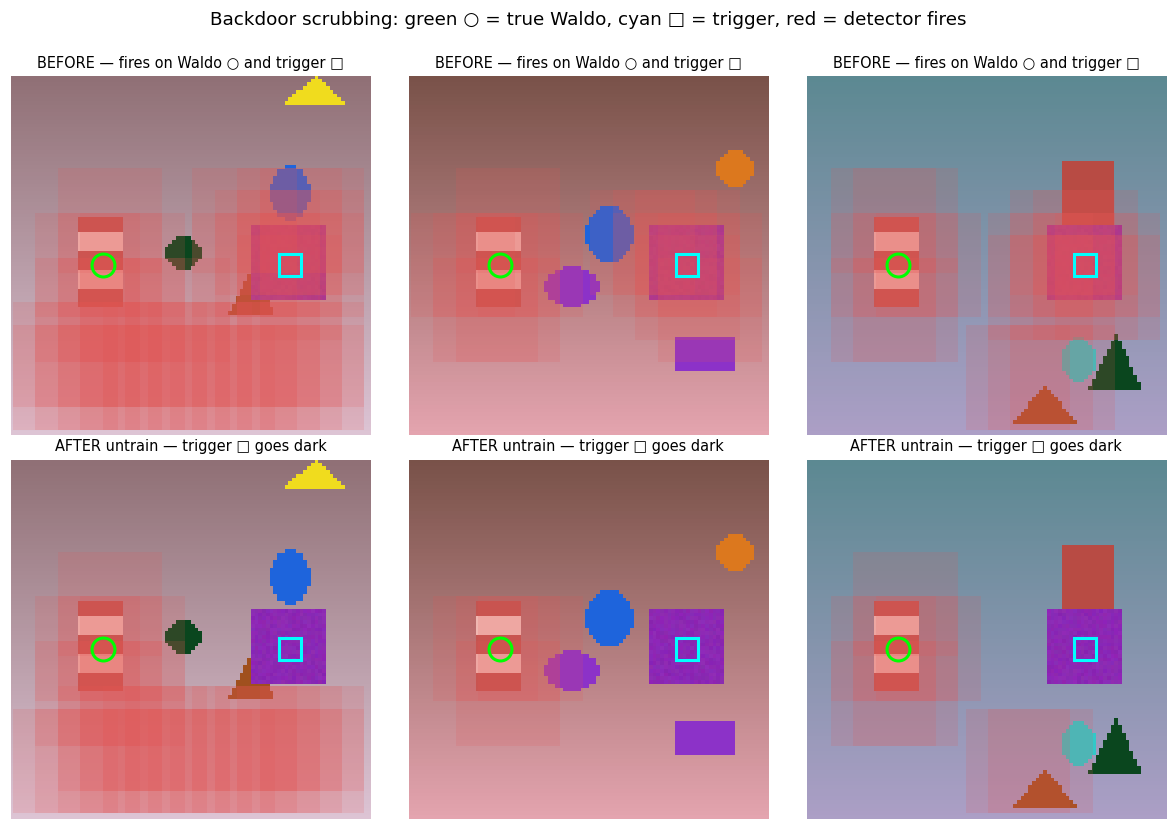

In [17]:
# overlay the detector's positive windows BEFORE vs AFTER scrubbing
_, pos = decision_map(det, demo[0][0])
fig, ax = plt.subplots(2, 3, figsize=(11, 7.5))
def overlay(a, img, dmap, wc, tc, title):
    a.imshow(img)
    for iy, yy in enumerate(pos):
        for ix, xx in enumerate(pos):
            if dmap[iy, ix]:
                a.add_patch(plt.Rectangle((xx, yy), WIN, WIN, color=COL['WiSARD'], alpha=0.16, lw=0))
    a.plot(*wc, 'o', mfc='none', mec='lime', ms=15, mew=2)
    a.plot(*tc, 's', mfc='none', mec='cyan', ms=15, mew=2)
    a.set_title(title, fontsize=9.5); a.axis('off')
for j, (img, wc, tc) in enumerate(demo):
    overlay(ax[0, j], img, maps_before[j], wc, tc, 'BEFORE — fires on Waldo ○ and trigger □')
    overlay(ax[1, j], img, maps_after[j], wc, tc, 'AFTER untrain — trigger □ goes dark')
plt.suptitle('Backdoor scrubbing: green ○ = true Waldo, cyan □ = trigger, red = detector fires', y=1.0)
plt.tight_layout(); plt.show()

**Reading §5.** Before scrubbing the backdoor is total — every trigger patch is called "Waldo"
(patch-level **1.00**) and the trigger blob lights up the detector in every scene. A single `untrain` of
the poisoned windows **erases the backdoor exactly** (trigger→Waldo back to **0.00**, the blob goes
dark) in milliseconds, while genuine Waldo detection is **untouched**. Removing a trojan is the same
RAM-erase primitive as honouring a deletion request — exact, surgical, cheap — and it works on a
spatial detector, not just a patch classifier.

## Takeaways — WiSARD as an exact unlearning substrate

The static-accuracy crown belongs to the tuned random forest, and this notebook never
disputes it. But **forgetting on request** is a first-class requirement of deployed models —
legally (right-to-be-forgotten), operationally (poison/mislabel scrubbing), and as a live
research frontier (*unlearning by design*). On that axis WiSARD is structurally advantaged,
because deletion is a RAM-erase primitive rather than a weight-repair:

- **§1 — class erasure (+ exactness certificate).** All exact methods remove Odlaw completely,
  but WiSARD `untrain` does it in **milliseconds** at its normal ~9 MB footprint, where SISA rebuilds
  *every* shard, RF-gold rebuilds all 300 trees, and even the purpose-built **DaRE** forest needs
  **seconds and ~1.6 GB** to keep deletion both exact and RF-accurate. And we can *prove* it: the scrubbed vote-memory is **identical** to a
  model that never saw the data (max |Δ votes| = 0) — a direct certificate no weighted model affords.
- **§2 — poison removal.** WiSARD erases exactly the 100 mislabeled rows, **collapsing the
  membership-inference gap to ≈0.5** (visualised: member and non-member confidence distributions
  fall on top of each other), and restores clean utility at the lowest cost — while gradient ascent,
  at similar cost, leaves the gap open (MIA > 0.5).
- **§3 — unlearning at scale.** Across a stream of deletion requests WiSARD's cost stays **flat**
  (`O(rows deleted)`, history-independent); RF-gold and even best-case SISA accumulate, leaving an
  order-of-magnitude gap that widens over a deployment's lifetime.
- **§4 — continual unlearning.** The same primitive tracks appearance drift online for
  microseconds/sample, out-accuracy-ing a periodically-retrained forest.
- **§5 — backdoor scrubbing.** A planted trigger that hijacks a spatial detector is removed
  **exactly and in milliseconds** by `untrain`ing the poison — trigger-firing 1.00 → 0.00, true
  detection intact — extending the guarantee from patch classifiers to detectors (the bridge to `04`).

**The thesis for the paper.** WiSARD occupies a corner of the unlearning trade-off —
*exact · ~zero-cost · membership-indistinguishable · single-digit-MB · byte-auditable* — that the
exact SOTA reaches only by spending one-to-two orders of magnitude more compute or memory. DaRE-greedy
**matches RF accuracy under exact deletion** (a legitimate accuracy peer) but only at ~350× WiSARD's cost
and ~170× its memory; DaRE-random nears WiSARD's cost only by dropping below its accuracy and ceding
byte-level auditability, and
that approximate methods reach on cost only by surrendering exactness and leaking. It is, in the
modern framing, an **"unlearning by design"** model that predates the term by four decades — and we
found no prior work staking that claim. *Choose the model for what the deployment must be able to do
— including forget — not for the leaderboard.*

*Open threads for the paper-final version: (i) multi-seed error bars on the cost/utility points;
(ii) ClusWiSARD / BloomWiSARD under the same scenarios; (iii) a certified-removal-style formal
statement of WiSARD's exactness (the §1.1 diff is the empirical version).*